## Redoing preprocessing of fastq into sequences for analysis

The preprocessing script is at [preprocessing.py](preprocessing.py). 
* Switch from AA seqs to DNA seqs
  * num of mutants cutoff is now 15 base pairs instead of 10 residues
* No quality filtering is done
* Source fastq files are what Phil generated

### Load in data

In [1]:
import gzip 

import Bio
import Bio.SeqIO

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datadir = "data/jared_PacBio_data_2"
bin_dir = "data/2D"

In [3]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")
WT_DNA = WT_fasta.seq
WT = WT_DNA.translate()

WT_DNA = WT_fasta.seq
print("WT (in this case the 2D parent)")
print(repr(WT_DNA), repr(WT), sep="\n")

WT (in this case the 2D parent)
Seq('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCA...TGA')
Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*')


In [4]:
sample_info = pd.read_csv(f"{bin_dir}/sample_info.csv")
sample_info

,bin_num,bin_name,category,num_samples,response
0,1,2D-R1-B1,High Hydroxylation,14,3
1,2,2D-R1-B2,Parent Hydroxylation,25,2
2,3,2D-R1-B3,Low Hydroxylation,186,1
3,4,2D-R1-B4,No Hydroxylation,675,0
4,5,2D-R1-B5,High Azidation,16,3
5,6,2D-R1-B6,Parent Azidation,27,2
6,7,2D-R1-B7,Low Azidation,174,1
7,8,2D-R1-B8,No Azidation,683,0


In [5]:
def read_text_file(filename): 
    """Read plain text file"""
    with open(filename, "rt") as fh:
        return [line.strip() for line in fh]

In [6]:
# read in all the sequences from all the bins
# a count the unique sequences (i.e. make histograms)
bin_pd_list = list()
for bin_num in sample_info.bin_num:
    bin_seqs = read_text_file(bin_dir + f"/bin{bin_num}_sequences.txt")
    bin_pd = pd.DataFrame(bin_seqs, columns=["sequence"])
    bin_pd_unique = bin_pd.sequence.value_counts().reset_index()
    bin_pd_unique.columns = ["sequence", "count"]
    bin_pd_unique["bin_num"] = bin_num
    bin_pd_unique = bin_pd_unique.reset_index()
    bin_pd_unique.rename(columns={'index':'seq_idx'}, inplace=True)
    bin_pd_unique["seq_idx"] += 1 # so that we can take log of seq_idx
    bin_pd_list.append(bin_pd_unique)
    
df = pd.concat(bin_pd_list, ignore_index=True)
df["bin_num"] = pd.Categorical(df["bin_num"])
df["is_wt"] = (df.sequence == WT_DNA)

In [7]:
df_wt = df[df.is_wt == True] # only select sequence that match the parent in this dataframe

### Read counts from Pacbio sequencing

* Marking the location of the WT DNA sequence

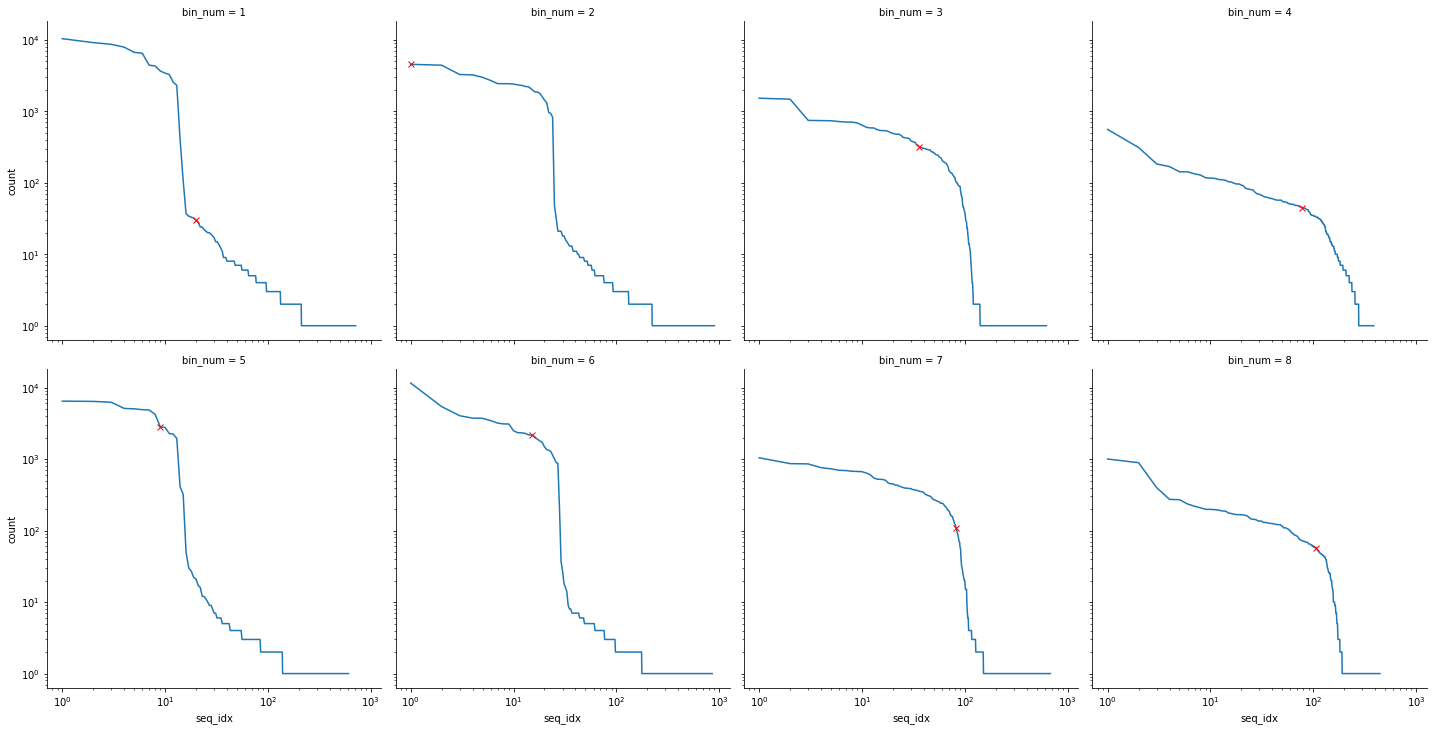

In [8]:
grid = sns.relplot(data=df, y="count", x="seq_idx", col="bin_num", col_wrap=4, kind="line")
grid.set(xscale="log", yscale="log")
for bin_num, ax in grid.axes_dict.items():
    df_wt_bin = df_wt[df_wt.bin_num == bin_num]
    ax.plot(df_wt_bin.seq_idx, df_wt_bin["count"], "rx")

* Hydroxylation (bins 1-4)
  * Parent 2D appears dominant in bin 2 (Parent Hydroxylation) only and not in other bins. 
* Azidization (Bins 5-8)
  * Parent 2D doesn't stand out in any bin. Looks best in Bin 5 (High Azidation).

In [9]:
sample_info["num_reads"] = np.zeros(len(sample_info), dtype=int)
sample_info["num_unique"] = np.zeros(len(sample_info), dtype=int)
sample_info["WT_rank"] = np.zeros(len(sample_info), dtype=int) * -1
sample_info["WT_pct"] = np.zeros(len(sample_info), dtype=int)

In [10]:
df_by_bin = df.groupby("bin_num")
for bin_num, bin_data in df_by_bin:
    bin_mask = (sample_info.bin_num == bin_num)
    num_reads = bin_data["count"].sum()
    sample_info.loc[bin_mask, "num_reads"] = num_reads
    sample_info.loc[bin_mask, "num_unique"] = len(bin_data)
    bin_wt = bin_data[bin_data.is_wt == True]
    sample_info.loc[bin_mask, "WT_rank"] = int(bin_wt.seq_idx.item())
    sample_info.loc[bin_mask, "WT_pct"] = int(bin_wt["count"].item() / num_reads * 100)

In [11]:
sample_info # cutoffs

,bin_num,bin_name,category,num_samples,response,num_reads,num_unique,WT_rank,WT_pct
0,1,2D-R1-B1,High Hydroxylation,14,3,74963,714,20,0
1,2,2D-R1-B2,Parent Hydroxylation,25,2,55970,900,1,8
2,3,2D-R1-B3,Low Hydroxylation,186,1,32457,623,36,0
3,4,2D-R1-B4,No Hydroxylation,675,0,9377,388,77,0
4,5,2D-R1-B5,High Azidation,16,3,57018,609,9,4
5,6,2D-R1-B6,Parent Azidation,27,2,73299,855,15,2
6,7,2D-R1-B7,Low Azidation,174,1,31568,680,83,0
7,8,2D-R1-B8,No Azidation,683,0,16263,446,107,0


* The *No Hydroxylation* and *No Azidization* groups have the largest number of samples but the smallest number of total reads. **Why?** 

### Add cutoffs

In [12]:
cutoffs = {}

# Hydroxylation
cutoffs[1] = 1000
cutoffs[2] = 1000 
cutoffs[3] = 100 
cutoffs[4] = 100 

# Azidization
cutoffs[5] = 1000
cutoffs[6] = 1000
cutoffs[7] = 100
cutoffs[8] = 100

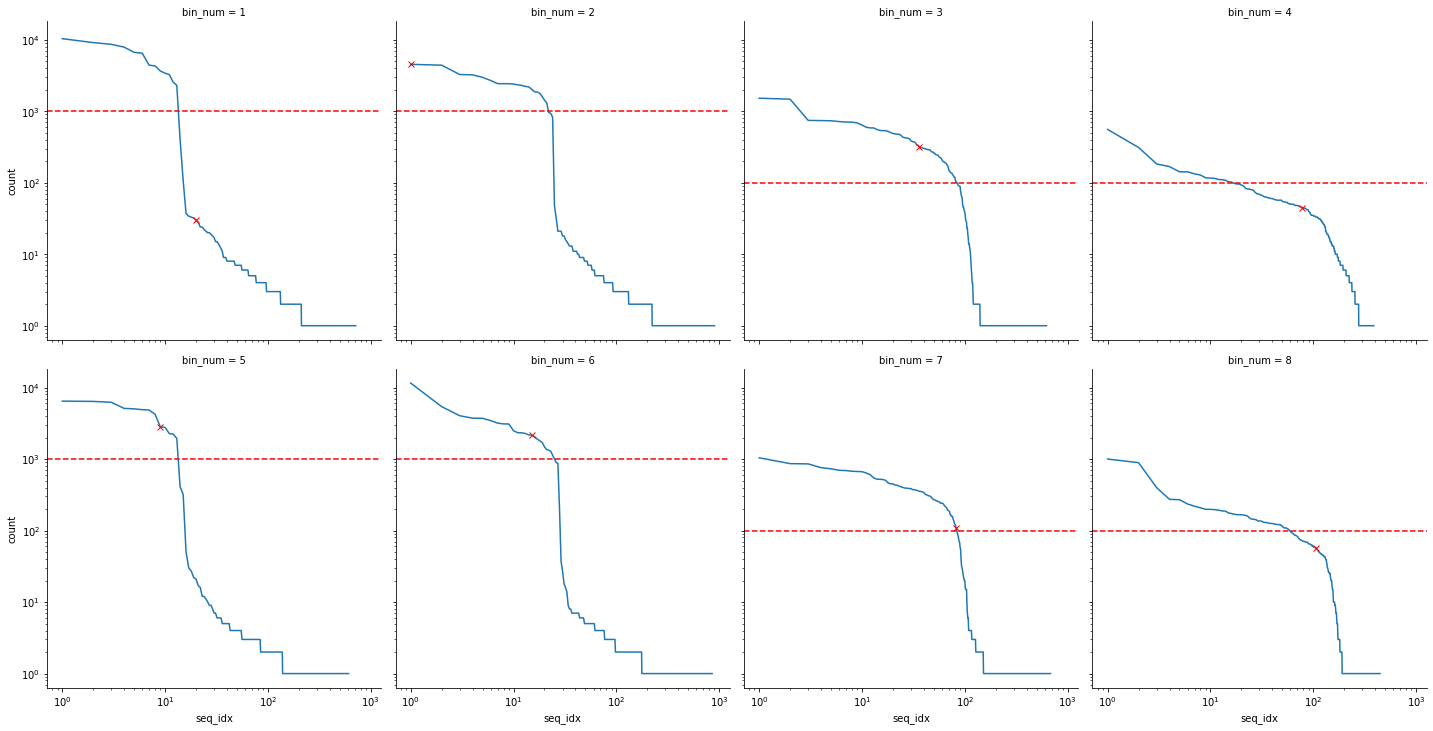

In [13]:
grid = sns.relplot(data=df, y="count", x="seq_idx", col="bin_num", col_wrap=4, kind="line")
grid.set(xscale="log", yscale="log")
for bin_num, ax in grid.axes_dict.items():
    df_wt_bin = df_wt[df_wt.bin_num == bin_num]
    ax.plot(df_wt_bin.seq_idx, df_wt_bin["count"], "rx")
    ax.axhline(cutoffs[bin_num], linestyle="--", color="r")
    
pass

In [14]:
df_cutoff = pd.concat([bin_data[bin_data["count"] >= cutoffs[bin_num]] 
                       for _, bin_data in df_by_bin])

### Save cutoff dataframe for further processing

# convert bin number 1-8 to response code
df_cutoff["response"] = sample_info.response.to_numpy()[df_cutoff.bin_num.to_numpy() - 1] 
df_cutoff

,seq_idx,sequence,count,bin_num,is_wt,response
0,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10336,1,False,3
1,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,9102,1,False,3
2,3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,8612,1,False,3
3,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,7872,1,False,3
4,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGCCACCGCAG...,6654,1,False,3
...,...,...,...,...,...,...
4822,54,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,109,8,False,0
4823,55,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,108,8,False,0
4824,56,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,106,8,False,0
4825,57,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,105,8,False,0


In [15]:
df_hydroxy = df_cutoff[df_cutoff.bin_num.isin([1,2,3,4])].copy()
df_azid = df_cutoff[df_cutoff.bin_num.isin([5,6,7,8])].copy()

In [16]:
df_hydroxy.to_pickle(f"{bin_dir}/hydroxy.pkl")
df_azid.to_pickle(f"{bin_dir}/azid.pkl")